In [1]:
import string
import numpy as np
import matplotlib
import matplotlib.pyplot as plt

from sklearn.feature_extraction.text import CountVectorizer
from sklearn.linear_model import SGDClassifier

import warnings

warnings.filterwarnings("ignore")

matplotlib.rc("xtick", labelsize=14)
matplotlib.rc("ytick", labelsize=14)

In [2]:
## Load the dataset

with open("data/full_set.txt", "r", encoding="utf-8") as file:
    reviews = file.readlines()

reviews = [line.strip() for line in reviews]

print("Total Reviews :", len(reviews))

print("\nFirst Five Reviews:\n")

for item in reviews[:5]:
    print(item)

Total Reviews : 3000

First Five Reviews:

So there is no way for me to plug iT in here in the US unless I go by a converter.	0
Good case, Excellent value.	1
Great for the jawbone.	1
Tied to charger for conversations lasting more than 45 minutes.MAJOR PROBLEMS!!	0
The mic is great.	1


In [3]:
## Separate Reviews and Labels
##Split each record into review text and sentiment label.

review_text = [row.split("\t")[0] for row in reviews]

review_labels = [row.split("\t")[1] for row in reviews]

y = np.array(review_labels, dtype="int8")

y = 2 * y - 1

print("Number of Reviews :", len(review_text))
print("Number of Labels :", len(y))

Number of Reviews : 3000
Number of Labels : 3000


In [4]:
## Create a Text Cleaning Function
##A function is created to remove unwanted characters such as digits and punctuation from the text.

def remove_characters(text, remove_list):

    for char in remove_list:
        text = text.replace(char, " ")

    return text

In [5]:
##Text Preprocessing

##In this step, the text data is cleaned by removing digits, punctuation marks, converting all text to lowercase, and removing common stop words.

# Remove digits

digits = [str(i) for i in range(10)]

text_without_digits = [remove_characters(text, digits) for text in review_text]

# Remove punctuation

text_without_punctuation = [
    remove_characters(text, list(string.punctuation))
    for text in text_without_digits
]

# Convert into lowercase

processed_text = [text.lower() for text in text_without_punctuation]

# Define stop words

stop_words = {
    "the", "a", "an", "i", "he", "she",
    "they", "to", "of", "it", "from",
    "one", "two", "ft"
}

# Remove stop words

split_text = [text.split() for text in processed_text]

final_sentences = [
    " ".join([word for word in sentence if word not in stop_words])
    for sentence in split_text
]

print("First 10 Cleaned Sentences:\n")

for sentence in final_sentences[:10]:
    print(sentence)

First 10 Cleaned Sentences:

so there is no way for me plug in here in us unless go by converter
good case excellent value
great for jawbone
tied charger for conversations lasting more than minutes major problems
mic is great
have jiggle plug get line up right get decent volume
if you have several dozen or several hundred contacts then imagine fun sending each them by
if you are razr owner you must have this
needless say wasted my money
what waste money and time


In [6]:
##Convert Text into Bag of Words
##Convert the processed text into numerical features using the CountVectorizer technique.

vectorizer = CountVectorizer(
    analyzer="word",
    max_features=4500
)

X = vectorizer.fit_transform(final_sentences)

data_matrix = X.toarray()

print("Feature Matrix Shape :", data_matrix.shape)

Feature Matrix Shape : (3000, 4500)


In [7]:
##Split the Dataset
###Split the dataset into training and testing data for model building and evaluation.

np.random.seed(0)

test_index = np.append(
    np.random.choice((np.where(y == -1))[0], 250, replace=False),
    np.random.choice((np.where(y == 1))[0], 250, replace=False)
)

train_index = list(set(range(len(review_labels))) - set(test_index))

X_train = data_matrix[train_index]
y_train = y[train_index]

X_test = data_matrix[test_index]
y_test = y[test_index]

print("Training Data Shape :", X_train.shape)
print("Testing Data Shape  :", X_test.shape)

Training Data Shape : (2500, 4500)
Testing Data Shape  : (500, 4500)


In [8]:
## Train the Logistic Regression Model
##Build and train the Logistic Regression classifier using the training dataset.

sentiment_model = SGDClassifier(
    loss="log_loss",
    penalty=None,
    random_state=42
)

sentiment_model.fit(X_train, y_train)

print("Model training completed successfully.")

Model training completed successfully.


In [9]:
##Evaluate Model Performance
# Predict on training and testing data

train_predictions = sentiment_model.predict(X_train)
test_predictions = sentiment_model.predict(X_test)

# Calculate training error

train_error = np.sum(
    (train_predictions > 0) != (y_train > 0)
)

train_error = train_error / len(y_train)

# Calculate testing error

test_error = np.sum(
    (test_predictions > 0) != (y_test > 0)
)

test_error = test_error / len(y_test)

print("Training Error :", train_error)

print("Testing Error  :", test_error)

print("\nTraining Accuracy :", round((1-train_error)*100,2),"%")

print("Testing Accuracy  :", round((1-test_error)*100,2),"%")

Training Error : 0.0032
Testing Error  : 0.166

Training Accuracy : 99.68 %
Testing Accuracy  : 83.4 %


In [13]:
##Margin Analysis
###Analyze the confidence level of predictions made by the Logistic Regression model.

def margin_count(model, X, gamma):

    probabilities = model.predict_proba(X)[:,1]

    margin_index = np.where(
        (probabilities > (0.5 + gamma)) |
        (probabilities < (0.5 - gamma))
    )[0]

    return len(margin_index)

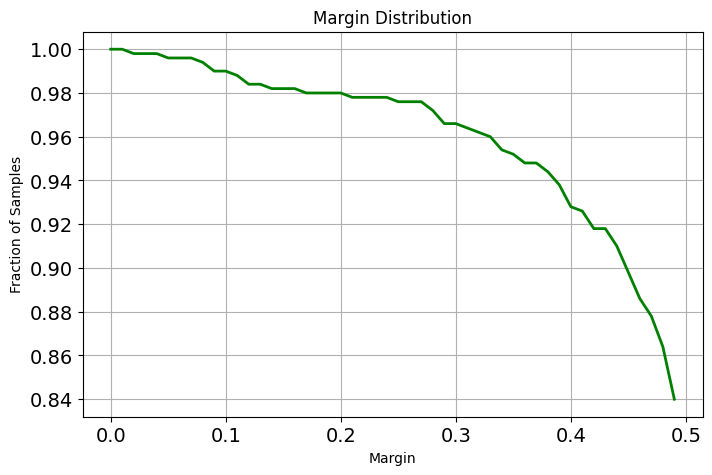

In [11]:
gamma_values = np.arange(0,0.5,0.01)

margin_result = np.vectorize(
    lambda g: margin_count(sentiment_model, X_test, g)
)

plt.figure(figsize=(8,5))

plt.plot(
    gamma_values,
    margin_result(gamma_values)/500,
    color="green",
    linewidth=2
)

plt.xlabel("Margin")

plt.ylabel("Fraction of Samples")

plt.title("Margin Distribution")

plt.grid(True)

plt.show()

In [15]:
##Analyze Margin Error
##In this step, we calculate the classification error for different margin values and visualize the relationship between margin and prediction error.

def margin_error(model, X, y, gamma):

    probabilities = model.predict_proba(X)[:, 1]

    selected = np.where(
        (probabilities > (0.5 + gamma)) |
        (probabilities < (0.5 - gamma))
    )[0]

    if len(selected) == 0:
        return 0

    errors = np.sum(
        (probabilities[selected] > 0.5) != (y[selected] > 0)
    )

    return errors / len(selected)

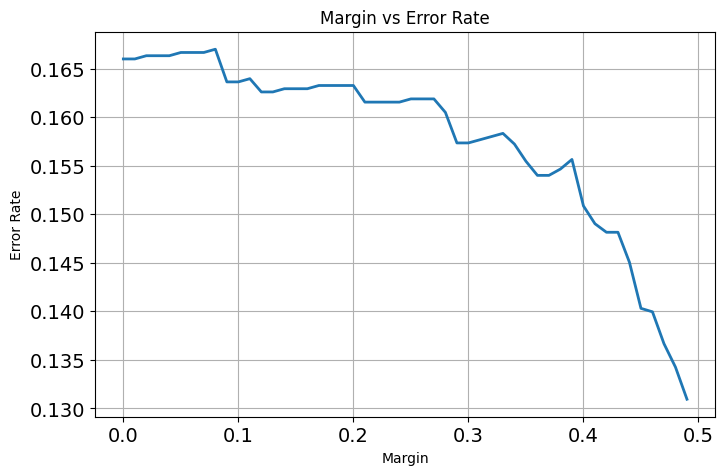

In [16]:
##Plot Margin Error Graph
gamma_values = np.arange(0, 0.5, 0.01)

margin_errors = np.vectorize(
    lambda g: margin_error(sentiment_model, X_test, y_test, g)
)

plt.figure(figsize=(8,5))

plt.plot(
    gamma_values,
    margin_errors(gamma_values),
    linewidth=2
)

plt.xlabel("Margin")

plt.ylabel("Error Rate")

plt.title("Margin vs Error Rate")

plt.grid(True)

plt.show()

In [17]:
## Identify Important Positive and Negative Words
# Extract feature names

vocabulary = np.array(
    sorted(vectorizer.vocabulary_, key=vectorizer.vocabulary_.get)
)

# Get model weights

weights = sentiment_model.coef_[0]

# Sort weights

sorted_index = np.argsort(weights)

# Most Negative Words

negative_words = vocabulary[sorted_index[:50]]

# Most Positive Words

positive_words = vocabulary[sorted_index[-50:]]

print("Top Negative Words:\n")

print(list(negative_words))

print("\n")

print("Top Positive Words:\n")

print(list(positive_words))

Top Negative Words:

[np.str_('poor'), np.str_('disappointment'), np.str_('wait'), np.str_('worst'), np.str_('lacks'), np.str_('waste'), np.str_('average'), np.str_('stupid'), np.str_('mediocre'), np.str_('then'), np.str_('cheap'), np.str_('bad'), np.str_('rude'), np.str_('put'), np.str_('make'), np.str_('management'), np.str_('none'), np.str_('stereotypes'), np.str_('started'), np.str_('unit'), np.str_('off'), np.str_('tables'), np.str_('money'), np.str_('fails'), np.str_('reason'), np.str_('uninteresting'), np.str_('literally'), np.str_('overpriced'), np.str_('calls'), np.str_('bored'), np.str_('mind'), np.str_('dislike'), np.str_('wasted'), np.str_('slow'), np.str_('crap'), np.str_('avoid'), np.str_('awful'), np.str_('hours'), np.str_('unless'), np.str_('earpiece'), np.str_('not'), np.str_('bland'), np.str_('predictably'), np.str_('weak'), np.str_('hear'), np.str_('cheesy'), np.str_('disappointing'), np.str_('minutes'), np.str_('break'), np.str_('directing')]


Top Positive Words:

